In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df = pd.read_csv('/content/Fishers maket.csv')

In [ ]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [ ]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [ ]:
df.isnull().sum()

,0
Species,0
Weight,0
Length1,0
Length2,0
Length3,0
Height,0
Width,0


In [ ]:
df.shape

(159, 7)

In [ ]:
df.dropna(inplace=True)

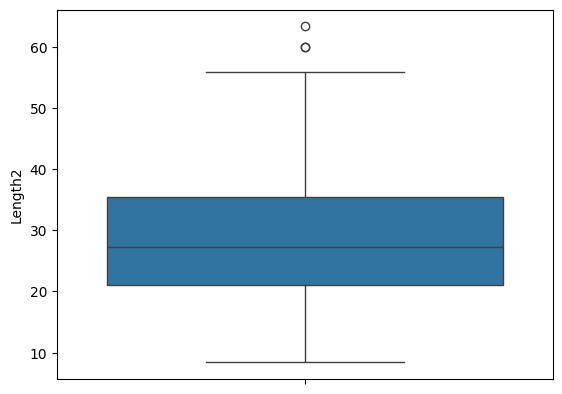

In [ ]:
sns.boxplot(df['Length2'])
plt.show()

In [ ]:
# Calculate Q1 and Q3
Q1 = df['Length2'].quantile(0.25)
Q3 = df['Length2'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['Length2'] >= lower_limit) & (df['Length2'] <= upper_limit)]

# Check the new shape
print(df.shape)

(156, 7)


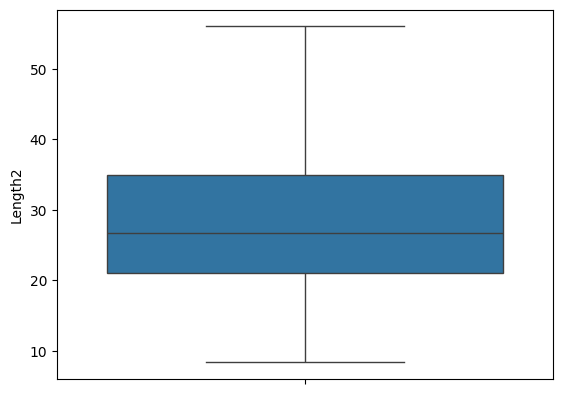

In [ ]:
sns.boxplot(df['Length2'])
plt.show()

In [ ]:
x = df[['Length2']]
y = df['Weight']

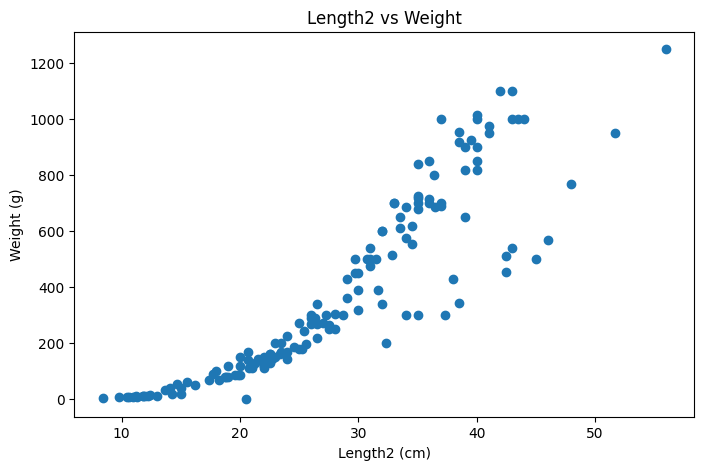

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(x, y)

plt.xlabel("Length2 (cm)")
plt.ylabel("Weight (g)")

plt.title("Length2 vs Weight")

plt.show()

In [ ]:
poly = PolynomialFeatures(degree=2)

x_poly = poly.fit_transform(x)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -254.52939505878976
Coefficients: [ 0.         15.39810799  0.22780657]


In [ ]:
y_train_pred = model.predict(x_train)

In [ ]:
y_test_pred = model.predict(x_test)

In [ ]:
result = pd.DataFrame({
    "Actual Weight": y_test,
    "Predicted Weight": y_test_pred
})

result.head()

,Actual Weight,Predicted Weight
96,225.0,246.241778
69,200.0,220.136762
82,110.0,169.293568
76,70.0,82.368400
114,700.0,627.067788


In [ ]:
print("Training Metrics")

print("Mean Absolute Error:",
      mean_absolute_error(y_train, y_train_pred))

print("Mean Squared Error:",
      mean_squared_error(y_train, y_train_pred))

print("Root Mean Squared Error:",
      np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("R2 Score:",
      r2_score(y_train, y_train_pred))

Training Metrics
Mean Absolute Error: 99.96006043323976
Mean Squared Error: 18590.981062349947
Root Mean Squared Error: 136.34874793099476
R2 Score: 0.8147729768288092


In [ ]:
print("Testing Metrics")

print("Mean Absolute Error:",
      mean_absolute_error(y_test, y_test_pred))

print("Mean Squared Error:",
      mean_squared_error(y_test, y_test_pred))

print("Root Mean Squared Error:",
      np.sqrt(mean_squared_error(y_test, y_test_pred)))

print("R2 Score:",
      r2_score(y_test, y_test_pred))

Testing Metrics
Mean Absolute Error: 108.32177783188735
Mean Squared Error: 19412.94556260332
Root Mean Squared Error: 139.3303468832376
R2 Score: 0.8142976634349709


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


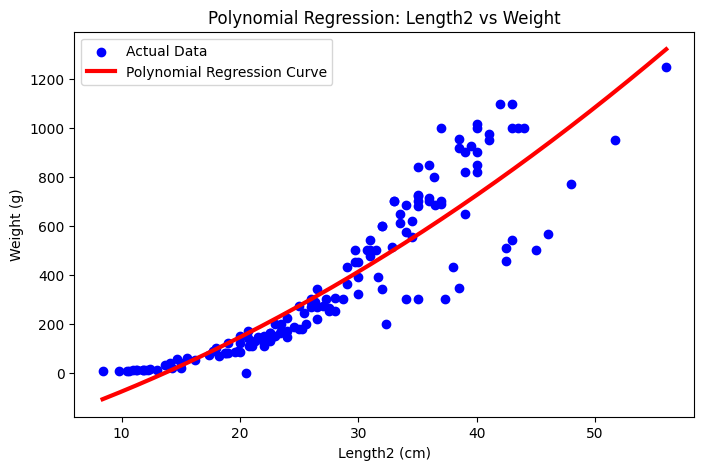

In [ ]:
x_grid = np.linspace(
    x.min().values[0],
    x.max().values[0],
    500
).reshape(-1,1)

x_grid_poly = poly.transform(x_grid)

y_grid = model.predict(x_grid_poly)

plt.figure(figsize=(8,5))

plt.scatter(x, y, color='blue', label='Actual Data')

plt.plot(
    x_grid,
    y_grid,
    color='red',
    linewidth=3,
    label='Polynomial Regression Curve'
)

plt.xlabel("Length2 (cm)")
plt.ylabel("Weight (g)")
plt.title("Polynomial Regression: Length2 vs Weight")

plt.legend()

plt.show()

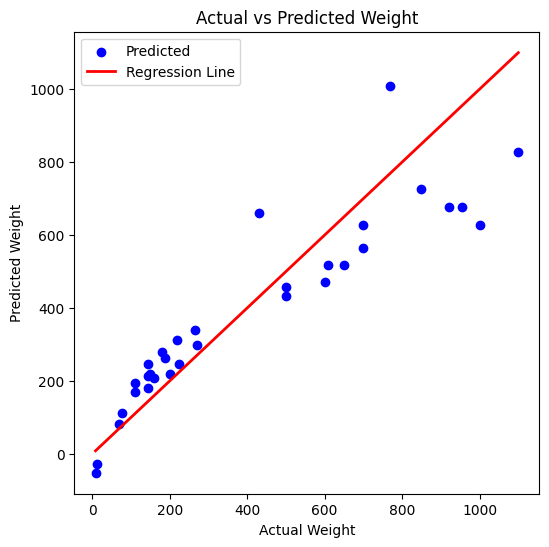

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred,
    color='blue',
    label='Predicted'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")

plt.title("Actual vs Predicted Weight")

plt.legend()

plt.show()